In [2]:
import pandas as pd

In [3]:
def process_data(diann_path, mumdia_path, pin_path):
    """
    Process DIA-NN and MuMDIA data for comparison.

    Args:
        diann_path: Path to DIA-NN parquet file
        mumdia_path: Path to MuMDIA mokapot.psms.txt file
        pin_path: Path to pin file

    Returns:
        tuple: (diann_data, mumdia_valid_data)
    """
    # Load DIA-NN data
    diann_data = pd.read_parquet(diann_path)

    # Load MuMDIA data
    mumdia_data = pd.read_csv(mumdia_path, sep="\t")
    pin_data = pd.read_csv(pin_path, sep="\t")

    # Merge and filter MuMDIA data
    mumdia_merged = pd.merge(
        mumdia_data,
        pin_data[["ScanNr", "filename", "charge"]],
        on=["filename", "ScanNr"],
        how="left",
    )
    mumdia_valid = mumdia_merged[
        (mumdia_data["mokapot q-value"] <= 0.1) & (mumdia_data["Label"])
    ]

    # Create Precursor.Id for MuMDIA data
    mumdia_valid["Precursor.Id"] = mumdia_valid["Peptide"] + mumdia_valid[
        "charge"
    ].astype(int).astype(str)

    return diann_data, mumdia_valid

# Astral

In [4]:
# Process Astral data
diann_astral, mumdia_astral_valid = process_data(
    "/home/robbe/MuMDIA/DIA-NN_output/Astral_no_mods/report.parquet",
    "/home/robbe/MuMDIA/results/astral/mokapot.psms.txt",
    "/home/robbe/MuMDIA/results/astral/outfile.pin",
)

/tmp/ipykernel_851989/775785660.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mumdia_valid["Precursor.Id"] = mumdia_valid["Peptide"] + mumdia_valid[


# Data Processing and Comparison

Process both Astral and TimsTOF datasets and create comparative visualizations.

In [5]:
# Process TimsTOF data
diann_timsconvert, mumdia_timsconvert_valid = process_data(
    "/home/robbe/MuMDIA/DIA-NN_output/timsconvert/report.parquet",
    "/home/robbe/MuMDIA/results/timsconvert/mokapot.psms.txt",
    "/home/robbe/MuMDIA/results/timsconvert/outfile.pin",
)

/tmp/ipykernel_851989/775785660.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mumdia_valid["Precursor.Id"] = mumdia_valid["Peptide"] + mumdia_valid[


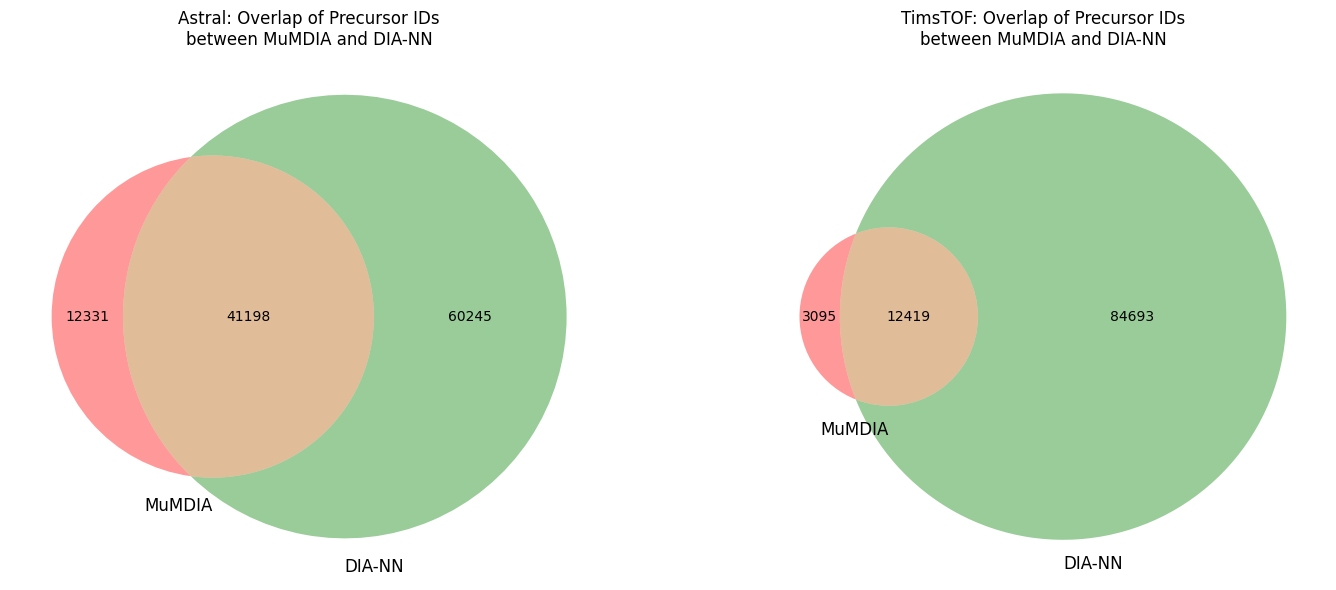

Astral Dataset:
  MuMDIA identifications: 53529
  DIA-NN identifications: 101443
  Overlap: 41198
  MuMDIA unique: 12331
  DIA-NN unique: 60245

TimsTOF Dataset:
  MuMDIA identifications: 15514
  DIA-NN identifications: 97112
  Overlap: 12419
  MuMDIA unique: 3095
  DIA-NN unique: 84693


In [6]:
# Create subfigures showing Venn diagrams for both datasets
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Astral Venn diagram
plt.sca(ax1)
mumdia_precursor_ids_astral = set(mumdia_astral_valid["Precursor.Id"])
diann_precursor_ids_astral = set(diann_astral["Precursor.Id"])
venn2(
    [mumdia_precursor_ids_astral, diann_precursor_ids_astral],
    set_labels=("MuMDIA", "DIA-NN"),
    ax=ax1,
)
ax1.set_title("Astral: Overlap of Precursor IDs\nbetween MuMDIA and DIA-NN")

# TimsTOF Venn diagram
plt.sca(ax2)
mumdia_precursor_ids_timsconvert = set(mumdia_timsconvert_valid["Precursor.Id"])
diann_precursor_ids_timsconvert = set(diann_timsconvert["Precursor.Id"])
venn2(
    [mumdia_precursor_ids_timsconvert, diann_precursor_ids_timsconvert],
    set_labels=("MuMDIA", "DIA-NN"),
    ax=ax2,
)
ax2.set_title("TimsTOF: Overlap of Precursor IDs\nbetween MuMDIA and DIA-NN")

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Astral Dataset:")
print(f"  MuMDIA identifications: {len(mumdia_precursor_ids_astral)}")
print(f"  DIA-NN identifications: {len(diann_precursor_ids_astral)}")
print(f"  Overlap: {len(mumdia_precursor_ids_astral & diann_precursor_ids_astral)}")
print(
    f"  MuMDIA unique: {len(mumdia_precursor_ids_astral - diann_precursor_ids_astral)}"
)
print(
    f"  DIA-NN unique: {len(diann_precursor_ids_astral - mumdia_precursor_ids_astral)}"
)

print(f"\nTimsTOF Dataset:")
print(f"  MuMDIA identifications: {len(mumdia_precursor_ids_timsconvert)}")
print(f"  DIA-NN identifications: {len(diann_precursor_ids_timsconvert)}")
print(
    f"  Overlap: {len(mumdia_precursor_ids_timsconvert & diann_precursor_ids_timsconvert)}"
)
print(
    f"  MuMDIA unique: {len(mumdia_precursor_ids_timsconvert - diann_precursor_ids_timsconvert)}"
)
print(
    f"  DIA-NN unique: {len(diann_precursor_ids_timsconvert - mumdia_precursor_ids_timsconvert)}"
)